### Install LightFM

In [3]:
!pip install -q lightfm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 12.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


### Import Dataset & Necessary Packages

In [85]:
import pandas as pd
import numpy as np
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from lightfm import LightFM
from lightfm.data import Dataset
from lightfm.evaluation import auc_score

In [74]:
path  = "/content/drive/MyDrive/CMPE 256/CMPE 256 -- Advanced Data Mining/main_timestamp.csv"
df = pd.read_csv(path)
df.head()

,distance,duration,gender,heart_rate,sport,userId,timestamp_start,timestamp_end,calories
0,56.245906,10810.0,male,142.672,bike,139383,1276037798,1276048608,3757.00
1,53.232915,10798.0,male,137.844,bike,139383,1279234743,1279245541,3472.00
2,9.404775,4838.0,male,158.678,run,212295,1274655206,1274660044,1054.00
3,5.550355,2916.0,male,154.348,run,212295,1271032062,1271034978,620.00
4,26.138077,6713.0,male,140.208,bike,139383,1288449864,1288456577,1529.96


### Preprocess & Fit LightFM
Several functions were created in support to train LightFM.
####From top to bottom:
- `create_train_test_split()`: This serves the purpose of splitting our data into a training and test set based on the `timestamp_start` feature. We will essentially predict "future" values.
- `list_of_users_and_sport()`: This creates two arrays that will be passed into LightFM to be predicted on. It is essentially the 1056 users called 43 times each to find the likelihood they will do a sport.
- `predict()`: We will take the list of users and sports from the `list_of_users_and_sport()` function and predict probabilities a user will like a sport.
- `feature_engineer()`: This handles the column creation and prepares the dataset in order to create the user and item features needed for the model.
- `create_features()`: This will create features for the user and item (sport) in order to passed into the `Dataset` package to create the interactions needed between the userId and sport.
- `create_dataset()`: This handles most of the function calls, getting the user and item features and fitting them into the `Dataset` package.
- `auc()`: This will take the predictions from the `predict()` function and return the average auc score.

At the very bottom of this block is the model fitting and displaying the scores for each user and item.

In [81]:
def create_train_test_split(df):
  training_ids = []
  testing_ids = []
  test_size = 0.2

  training_size = 1 - test_size

  uids = df['userId'].unique()
  for userId in uids:
    subset = df[df['userId'] == userId]
    values = np.sort(df[df['userId'] == userId].timestamp_start.values)

    # if only one values, make it appear in both
    training_length = int(training_size * len(values))
    if training_length <= 1:
      trainset = values
      testset = values
    else:
      trainset = values[:training_length]
      testset = values[training_length:]

    training_ids.extend(subset[subset['timestamp_start'].isin(trainset)].index)
    testing_ids.extend(subset[subset['timestamp_start'].isin(testset)].index)

  train_df, test_df = df.iloc[training_ids], df.iloc[testing_ids]
  return train_df, test_df

def list_of_users_and_sport(dataset):
  predict_user = []
  predict_item = []
  for i in range(len(dataset.mapping()[0])):
    for _ in range(len(dataset.mapping()[2])):
      predict_user.append(i)
  for _ in range(len(dataset.mapping()[0])):
    for i in range(len(dataset.mapping()[2])):
      predict_item.append(i)
  return predict_user, predict_item

def predict(model, dataset):
  predict_user, predict_item = list_of_users_and_sport(dataset)
  scores = model.predict(predict_user, predict_item)
  score = np.array(scores).reshape(-1, 43)
  predicted = pd.DataFrame(score, index=dataset.mapping()[0].keys(), columns=dataset.mapping()[2].keys())
  return predicted

def feature_engineer(df):
  df['hour_start'] = df['timestamp_start'].apply(lambda x: datetime.datetime.fromtimestamp(x).hour)
  df['workout_window'] = df['hour_start'].apply(lambda x: 'morning' if x < 11 else 'afternoon' if x < 17 else 'evening')
  df['gender'] = df['gender'].apply(lambda x: 1 if x == 'male' else 2 if x == "unknown" else 0)
  df['heartrate_per_user'] = df.groupby(['userId', 'sport'])['heart_rate'].transform('mean')
  df['cal_per_user'] = df.groupby(['userId', 'sport'])['calories'].transform('mean')
  df['duration'] = df['duration'].apply(lambda x: x/3600)
  df['duration_per_user'] = df.groupby(['userId', 'sport'])['duration'].transform('mean')
  return df

def create_features(df):
  df = feature_engineer(df)
  user_items = pd.get_dummies(df[['gender', 'heartrate_per_user','cal_per_user', 'duration_per_user']])
  user_feat = user_items.columns.values
  user_feature_dict = user_items.to_dict(orient='records')

  sport_items = pd.get_dummies(df[['duration', 'distance']])
  sport_feat = sport_items.columns.values
  sport_feature_dict = sport_items.to_dict(orient='records')
  return df, user_feat, sport_feat, user_feature_dict, sport_feature_dict

def create_dataset(df):
  df, user_feat, sport_feat, user_feature_dict, sport_feature_dict = create_features(df)
  train_df, test_df = create_train_test_split(df)
  dataset = Dataset()
  dataset.fit(users=df.userId.values, items=df.sport.values, user_features=user_feat, item_features=sport_feat)
  user_features = dataset.build_user_features((u_id, feat) for u_id, feat in zip(df['userId'], user_feature_dict))
  sport_features = dataset.build_item_features((sport, feat) for sport, feat in zip(df['sport'], sport_feature_dict))
  train_interactions, train_weights = dataset.build_interactions((u_id, sport) for u_id, sport in zip(train_df['userId'], train_df['sport']))
  test_interactions, test_weights = dataset.build_interactions((u_id, sport) for u_id, sport in zip(test_df['userId'], test_df['sport']))
  return dataset, user_features, sport_features, train_interactions, train_weights, test_interactions, test_weights, train_df, test_df

def auc(model, test, train, user_features, sport_features):
  train_auc = auc_score(model, train, user_features=user_features, item_features=sport_features).mean()
  test_auc = auc_score(model, test, user_features=user_features, item_features=sport_features).mean()
  return train_auc, test_auc

dataset, user_features, sport_features, train, train_weight, test, test_weight, train_df, test_df = create_dataset(df)

model = LightFM(no_components= 20, loss='warp')
model.fit(train, user_features=user_features, item_features=sport_features, epochs=30, sample_weight=train_weight, verbose=True)
train_auc, test_auc = auc(model, test, train, user_features, sport_features)
print("\nTrain AUC: %s \nTest AUC: %s" % (train_auc, test_auc))
predicted_df = predict(model, dataset)
predicted_df.head(10)

Epoch: 100%|██████████| 30/30 [00:09<00:00,  3.15it/s]


Train AUC: 0.9666923 
Test AUC: 0.9770515


,bike,run,bike (transport),mountain bike,walk,cross-country skiing,downhill skiing,circuit training,gymnastics,indoor cycling,...,snowboarding,kite surfing,windsurfing,squash,badminton,table tennis,rugby,sailing,martial arts,treadmill walking
139383,-0.038116,-0.110334,0.569193,0.216406,-0.057704,0.461065,-1.019007,-0.548219,-0.204142,-0.158240,...,-0.343699,-0.416088,-0.469591,-0.291756,-0.255194,-0.307129,-0.310016,-0.373059,-0.410221,-0.266706
212295,0.018688,0.065461,-0.179481,-0.060674,-1.026739,-1.412743,-1.434428,-0.579931,-0.179953,-1.011786,...,-0.346212,-0.429317,-0.502126,-0.267520,-0.236440,-0.289023,-0.295905,-0.402982,-0.382736,-0.267216
368603,0.072375,0.224955,-0.862217,-0.316858,-1.846737,-3.022343,-1.771618,-0.611959,-0.164959,-1.726332,...,-0.351727,-0.443496,-0.534176,-0.252419,-0.224099,-0.281295,-0.284535,-0.435867,-0.364720,-0.268386
653747,0.038319,0.121109,-0.409546,-0.147366,-1.298336,-1.932577,-1.544127,-0.585461,-0.172305,-1.245609,...,-0.344159,-0.430625,-0.508920,-0.255306,-0.228863,-0.282460,-0.287963,-0.411279,-0.365012,-0.267838
791908,0.022469,0.074188,-0.215139,-0.074770,-1.075202,-1.514255,-1.453837,-0.587492,-0.180560,-1.052925,...,-0.347435,-0.431818,-0.508345,-0.270793,-0.237662,-0.291926,-0.296688,-0.409045,-0.390345,-0.268602
983950,0.039616,0.123054,-0.437170,-0.159257,-1.298550,-1.949785,-1.538620,-0.594695,-0.173562,-1.246308,...,-0.349945,-0.435729,-0.515558,-0.261538,-0.234527,-0.288142,-0.293494,-0.416637,-0.371606,-0.268873
846598,0.080815,0.245681,-0.964259,-0.355012,-1.995383,-3.320911,-1.841997,-0.629942,-0.166633,-1.855670,...,-0.360574,-0.452397,-0.546850,-0.257122,-0.227631,-0.284870,-0.291522,-0.447229,-0.373928,-0.271720
81753,0.003255,0.016999,0.016558,0.013752,-0.798170,-0.967487,-1.337940,-0.572501,-0.186766,-0.810318,...,-0.346555,-0.427396,-0.495510,-0.276667,-0.238942,-0.293827,-0.300251,-0.398173,-0.396526,-0.270904
508935,-0.002444,0.002504,0.083391,0.037441,-0.719235,-0.826298,-1.308208,-0.579564,-0.194776,-0.738265,...,-0.349387,-0.430409,-0.498141,-0.286767,-0.246916,-0.305399,-0.308049,-0.403100,-0.411111,-0.269010
65547,0.097152,0.297689,-1.186599,-0.436498,-2.283698,-3.885955,-1.964435,-0.639564,-0.160543,-2.112162,...,-0.361574,-0.457654,-0.557501,-0.255026,-0.221318,-0.281808,-0.287673,-0.456169,-0.371736,-0.271676


### Precision @ K & Recall @ K
We first make a list of users and the sports they did, sorting them in how often they did them. The bottom two cell blocks find the precision and recall from k=1 to k=6 for the training and test set. The plot is displayed at the bottom.

In [82]:
user_df_train = train_df.groupby('userId')['sport'].apply(list)
unique_users = train_df['userId'].unique()
user_to_sport_train = {}
for uid in unique_users:
  data = {}
  for d in user_df_train[uid]:
    data[d] = 1 + data.get(d, 0)
  sorted_dict = dict(sorted(data.items(), key=lambda item: item[1], reverse=True))
  user_to_sport_train[uid] = list(sorted_dict)

user_df_test = test_df.groupby('userId')['sport'].apply(list)
unique_users = test_df['userId'].unique()
user_to_sport_test = {}
for uid in unique_users:
  data = {}
  for d in user_df_test[uid]:
    data[d] = 1 + data.get(d, 0)
  sorted_dict = dict(sorted(data.items(), key=lambda item: item[1], reverse=True))
  user_to_sport_test[uid] = list(sorted_dict)

In [83]:
precisions_train = []
recalls_train = []
for k in range(1, 7):
  precision = 0
  recall = 0
  for user, sports in user_to_sport_train.items():
    sport = set(sports[:k])
    predicted = predicted_df.loc[user].sort_values(ascending=False).index[:k]
    precision += len(sport.intersection(predicted)) / k
    recall += len(sport.intersection(predicted)) / len(sports)
  precision_at_k = precision / train_df['userId'].nunique()
  recall_at_k = recall / train_df['userId'].nunique()
  print(f"Precision @ {k}: {precision_at_k}")
  print(f"Recall @ {k}: {recall_at_k}")
  precisions_train.append(precision_at_k)
  recalls_train.append(recall_at_k)

Precision @ 1: 0.4308712121212121
Recall @ 1: 0.2528796145983647
Precision @ 2: 0.5369318181818182
Recall @ 2: 0.541798566017316
Precision @ 3: 0.4479166666666647
Recall @ 3: 0.6415490470177972
Precision @ 4: 0.3849431818181818
Recall @ 4: 0.7253164081289077
Precision @ 5: 0.32102272727272324
Recall @ 5: 0.7466972552910052
Precision @ 6: 0.27304292929292995
Recall @ 6: 0.7562304593554593


Precision @ 1: 0.4251893939393939
Recall @ 1: 0.3035206980519481
Precision @ 2: 0.5137310606060606
Recall @ 2: 0.6454241071428569
Precision @ 3: 0.4024621212121183
Recall @ 3: 0.7360344516594512
Precision @ 4: 0.33830492424242425
Recall @ 4: 0.8177038239538237
Precision @ 5: 0.27916666666666334
Recall @ 5: 0.8382925234487733
Precision @ 6: 0.236268939393938
Recall @ 6: 0.8476213023088018


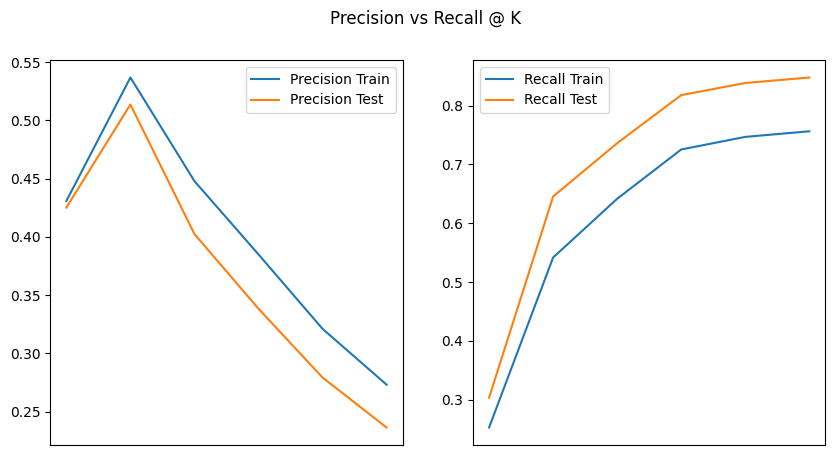

In [84]:
precisions_test = []
recalls_test = []
for k in range(1, 7):
  precision = 0
  recall = 0
  for user, sports in user_to_sport_test.items():
    sport = set(sports[:k])
    predicted = predicted_df.loc[user].sort_values(ascending=False).index[:k]
    precision += len(sport.intersection(predicted)) / k
    recall += len(sport.intersection(predicted)) / len(sports)
  precision_at_k = precision / test_df['userId'].nunique()
  recall_at_k = recall / test_df['userId'].nunique()
  print(f"Precision @ {k}: {precision_at_k}")
  print(f"Recall @ {k}: {recall_at_k}")
  precisions_test.append(precision_at_k)
  recalls_test.append(recall_at_k)

x = np.arange(len(precisions_test))
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.lineplot(x=x, y=precisions_train, label='Precision Train', ax=ax[0])
sns.lineplot(x=x, y=precisions_test, label='Precision Test', ax=ax[0])
sns.lineplot(x=x, y=recalls_train, label='Recall Train', ax=ax[1])
sns.lineplot(x=x, y=recalls_test, label='Recall Test', ax=ax[1])
fig.suptitle('Precision vs Recall @ K')
ax[0].set_xticks([])
ax[1].set_xticks([])
fig.show()